# Loading dataset

In [2]:

import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

# Dataset Overview

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
# Check missing values:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
# Check duplicate values:
df.duplicated().sum()

0

# Data Cleaning

In [6]:
# Convert dates:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [7]:
# Create new features:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter

In [8]:
#Shipping days:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [9]:
# Profit margin:
df['Profit Margin'] = (
    df['Profit'] / df['Sales']
) * 100

# First KPI Analysis

In [10]:
#Total Revenue
total_sales = df['Sales'].sum()
print(f"Revenue: ${total_sales:,.2f}")

Revenue: $2,297,200.86


In [11]:
#Total profit:
total_profit = df['Profit'].sum()
print(f"Profit: ${total_profit:,.2f}")

Profit: $286,397.02


In [36]:
# Total Orders
orders = df['Order ID'].nunique()
print(orders)

5009


In [13]:
# Total customers
customers = df['Customer ID'].nunique()
print(customers)

793


# Category Analysis

In [14]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


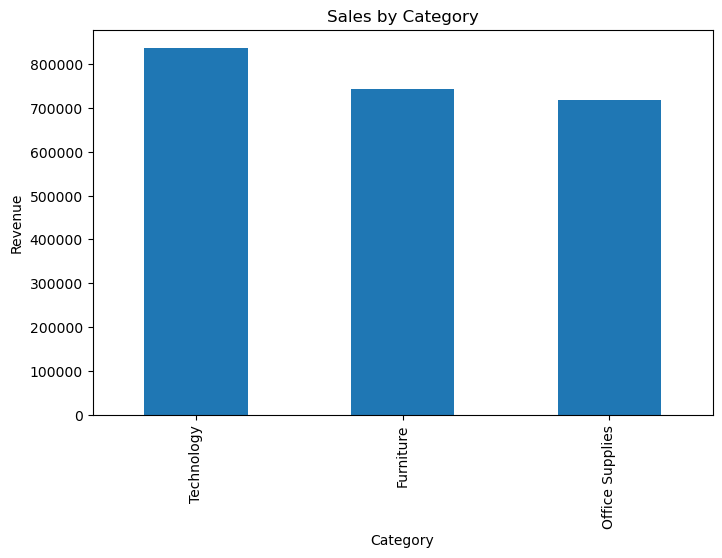

In [15]:
import matplotlib.pyplot as plt

category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Sales by Category')
plt.ylabel('Revenue')
plt.show()

# Region Analysis

In [16]:
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


# Top Products

In [17]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


# Monthly Sales Trend

In [18]:
monthly_sales = (
    df.groupby('Month Name')['Sales']
      .sum()
)

In [19]:
monthly_sales = (
    df.groupby(
        df['Order Date'].dt.to_period('M')
    )['Sales']
    .sum()
)

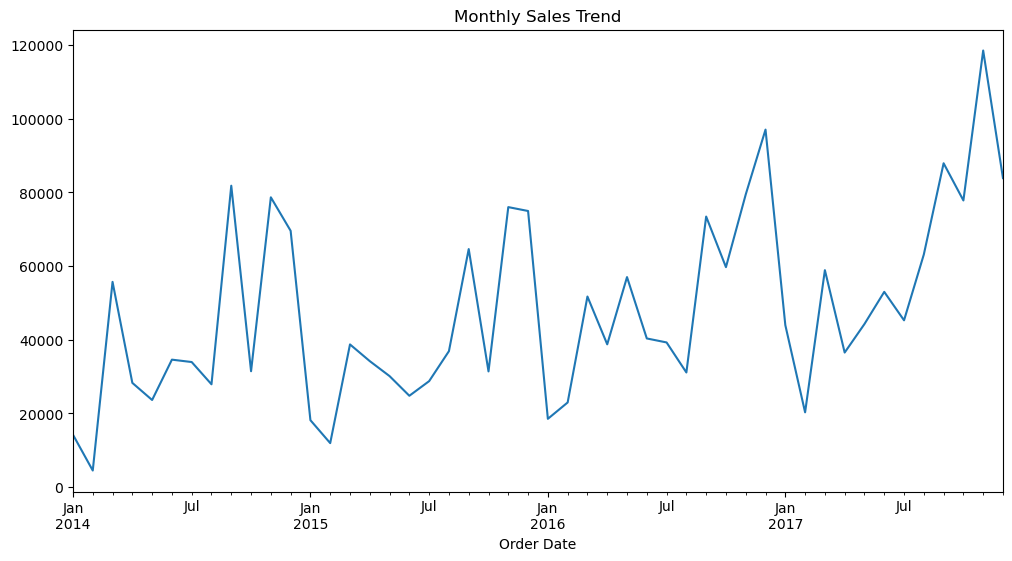

In [20]:
monthly_sales.plot(figsize=(12,6))
plt.title("Monthly Sales Trend")
plt.show()

# Customer Segmentation

In [21]:
segment_sales = (
    df.groupby('Segment')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(segment_sales)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


# Discount vs Profit Analysis

In [22]:
discount_profit = df.groupby('Discount')['Profit'].mean()

print(discount_profit)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


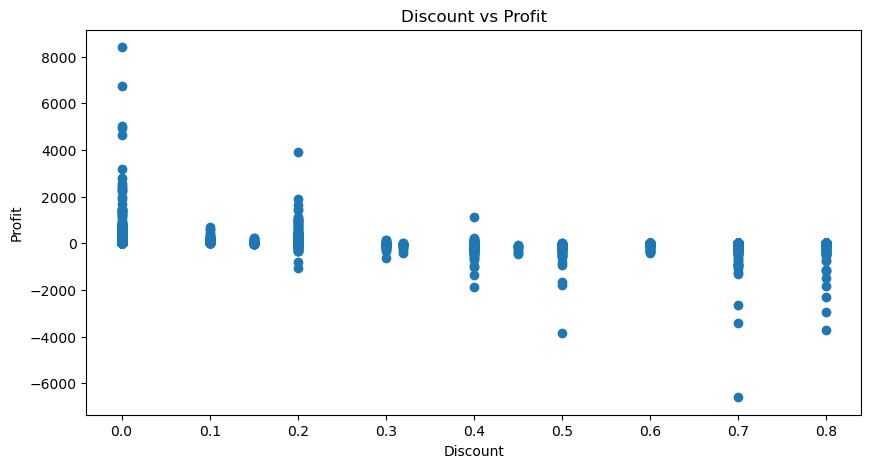

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(df['Discount'], df['Profit'])

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")

plt.show()

# Find Loss-Making Products

In [24]:
loss_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values()
      .head(10)
)

print(loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


# State-Level Analysis

In [25]:
state_profit = (
    df.groupby('State')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(state_profit.head(10))

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


In [26]:
print(state_profit.tail(10))

State
Oregon            -1190.4705
Florida           -3399.3017
Arizona           -3427.9246
Tennessee         -5341.6936
Colorado          -6527.8579
North Carolina    -7490.9122
Illinois         -12607.8870
Pennsylvania     -15559.9603
Ohio             -16971.3766
Texas            -25729.3563
Name: Profit, dtype: float64


# Monthly Trend Analysis

In [27]:
#Convert dates first
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [28]:
# Create Month-Year
df['MonthYear'] = df['Order Date'].dt.to_period('M')

In [29]:
#Monthly Revenue:
monthly_sales = (
    df.groupby('MonthYear')['Sales']
      .sum()
)

print(monthly_sales.head())

MonthYear
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='MonthYear'>

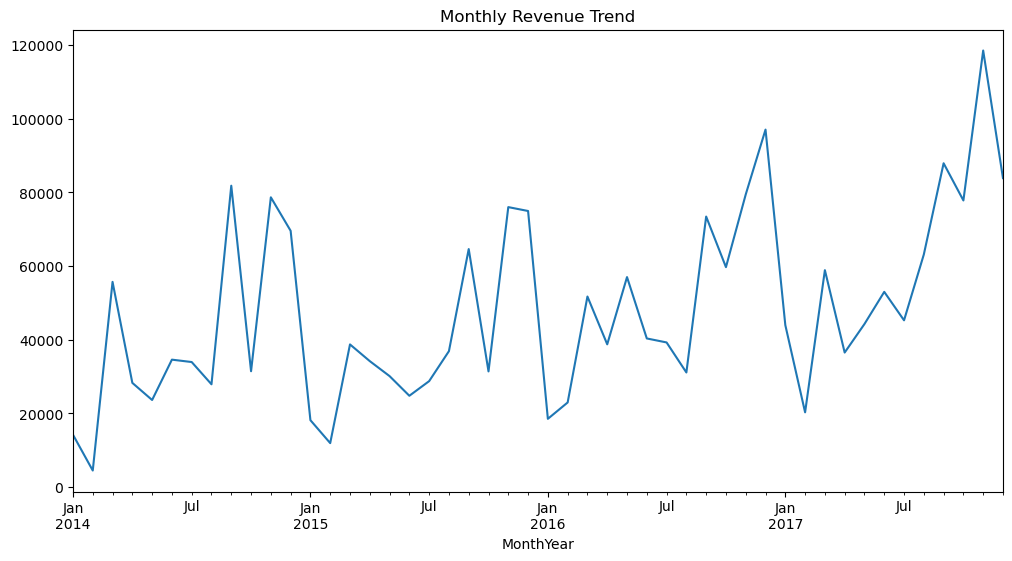

In [30]:
monthly_sales.plot(
    figsize=(12,6),
    title='Monthly Revenue Trend'
)

# Top Customers

In [31]:
top_customers = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [32]:
top_profit_customers = (
    df.groupby('Customer Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_profit_customers)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


# Create New Features for Dashboard

In [33]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

df['Shipping Days'] = (
    pd.to_datetime(df['Ship Date'])
    - pd.to_datetime(df['Order Date'])
).dt.days

df['Year'] = pd.to_datetime(df['Order Date']).dt.year

df['Month'] = pd.to_datetime(df['Order Date']).dt.month_name()

In [34]:
df.to_csv('superstore_cleaned.csv', index=False)

In [35]:
df.to_csv("superstore_cleaned.csv", index=False)